# Japan — F-Score grid study: basket k = 20, random draws = 2000

One cell of the reviewer-suggested 3 x 3 x 2 grid (basket sizes 20/25/30 x
random-sample sizes 1,000/2,000/5,000 x two markets). Signals come from the
team-computed workbook (`data/processed/`, exact Piotroski conventions,
financial firms removed); prices from the cached Yahoo data. Formations are
July 1 of **2003-2025** (23 chained holding years) using score year T-1 —
one conservative timing rule for both markets; the first scoreable workbook
year is 2002 (the 2000/2001 sheets have no scoreable firms since the panel
needs t-1 and t-2 history), so 2000-2002 formations cannot exist. The
evaluation window ends 2025-12-31. Note the panel resolves to *currently
listed* Yahoo symbols, so the early-2000s universe is survivorship-tilted —
disclosed as a data limitation. The value control falls back to the universe
in years before B/M coverage begins (flagged in the diagnostics).

Peer-review design points (see `src/fscore/grid.py` docstring): explicit
random basis = full eligible universe with fresh draws each year and reported
overlap; a non-F-Score random control; strict F ≥ 8 portfolio; universe EW
and plain universe minimum-variance controls; denoised (not detoned) GMV;
primary measure fixed in advance = net-of-cost Sharpe (20 bp per side,
rf = 0); and the synergy test D = Sharpe(GMV) − Sharpe(EW) computed per
basket. All figures are saved at dpi = 300.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parents[1]
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from fscore.data.team_scores import load_team_scores, sectors_from_scores
from fscore.grid import run_grid

MARKET, K, N_MC = "japan", 20, 2000
YEARS = list(range(2003, 2026))
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
OUT = ROOT / "results" / "grid"; OUT.mkdir(parents=True, exist_ok=True)
TAG = "japan_k20_mc2000"

scores = load_team_scores(MARKET, ROOT / "data")
prices = pd.read_csv(ROOT / "data" / f"{MARKET}_prices.csv.gz", parse_dates=["date"])
sectors = sectors_from_scores(scores)
study = run_grid(MARKET, scores, prices, sectors, YEARS, k=K, n_mc=N_MC,
                 n_gmv=300, seed=42)
diag = study.diagnostics()
diag.round(3)

,universe,dropped_no_price,bm_coverage,k,value_fallback,value_basket_size,n_fscore_high,fscore_mean,fscore_basket_min,overlap_random_vs_fscore,overlap_expected
year,,,,,,,,,,,
2003,53,8,0,20,True,53,7,5.566,6.0,0.375,0.377
2004,53,9,0,20,True,53,11,6.660,7.0,0.379,0.377
2005,59,8,0,20,True,59,25,7.085,8.0,0.342,0.339
2006,60,5,0,20,True,60,17,6.683,7.0,0.332,0.333
2007,55,2,0,20,True,55,13,6.691,7.0,0.364,0.364
2008,54,3,0,20,True,54,5,5.944,6.0,0.371,0.370
2009,64,4,0,20,True,64,10,5.969,7.0,0.313,0.312
2010,73,4,0,20,True,73,0,4.671,5.0,0.275,0.274
2011,76,3,0,20,True,76,13,6.066,7.0,0.263,0.263


### 1. Summary (primary measure: net-of-cost Sharpe; rf = 0, costs 20 bp per side on one-way turnover)

In [2]:
summary = study.summary()
summary.round(3)

,cum_return,ann_return,ann_vol,sharpe,max_drawdown,net_ann_return,net_sharpe
fscore_EW,8.006,0.105,0.211,0.497,-0.569,0.102,0.485
fscore_GMV,2.594,0.060,0.181,0.330,-0.566,0.057,0.315
fscore_GMVsec,4.130,0.077,0.188,0.410,-0.492,0.074,0.396
fscore_high_EW,5.845,0.091,0.215,0.424,-0.610,0.088,0.411
value_EW,8.344,0.107,0.215,0.496,-0.555,0.104,0.484
universe_EW,7.569,0.102,0.211,0.485,-0.555,0.100,0.473
universe_GMV,3.109,0.066,0.174,0.380,-0.519,0.063,0.365


### 2. Yearly returns (July–June holding years; final year ends Dec 2025)

In [3]:
yearly = study.yearly_returns()
(yearly * 100).round(1)

,fscore_EW,fscore_GMV,fscore_GMVsec,fscore_high_EW,value_EW,universe_EW,universe_GMV
date,,,,,,,
2003,8.5,3.3,6.9,1.3,16.3,16.3,3.1
2004,9.6,4.9,8.0,15.1,8.9,8.9,10.1
2005,37.6,15.9,27.5,39.8,36.3,36.3,26.2
2006,18.7,24.6,20.5,18.3,16.6,16.6,18.6
2007,-10.4,-13.4,-11.9,-9.1,-5.7,-5.7,-1.8
2008,-40.3,-23.0,-32.0,-46.4,-41.2,-41.2,-22.9
2009,22.8,-7.4,13.4,16.1,28.7,28.7,-7.1
2010,4.5,3.6,2.0,-1.5,6.9,6.9,7.0
2011,-17.8,-15.1,-13.7,-14.3,-18.0,-18.0,-13.3


### 3. Placement vs the random distributions

In [4]:
rows = {}
for pool, label in [("mc_ew", "random (full universe)"),
                    ("mc_nonf_ew", "random (non-F-Score names)")]:
    frame = getattr(study, pool)
    if frame.shape[1]:
        for stat in ["sharpe", "ann_return"]:
            rows[(label, stat)] = study.placement("fscore_EW", pool, stat)
placement = pd.DataFrame(rows).T
placement.round(3)

percentile  p_value  n_draws  \
random (full universe)     sharpe           0.743    0.257   2000.0   
                           ann_return       0.657    0.343   2000.0   
random (non-F-Score names) sharpe           0.821    0.179   2000.0   
                           ann_return       0.682    0.318   2000.0   

                                       random_mean  random_std  fscore  
random (full universe)     sharpe            0.468       0.044   0.497  
                           ann_return        0.101       0.009   0.105  
random (non-F-Score names) sharpe            0.461       0.039   0.497  
                           ann_return        0.101       0.008   0.105

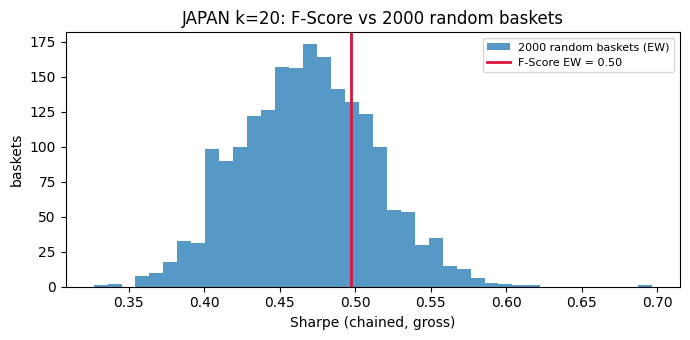

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sh = study.mc_metric(study.mc_ew, "sharpe")
ax.hist(sh, bins=40, alpha=0.75, label=f"{N_MC} random baskets (EW)")
fs = placement.loc[("random (full universe)", "sharpe"), "fscore"]
ax.axvline(fs, color="crimson", lw=2, label=f"F-Score EW = {fs:.2f}")
ax.set_xlabel("Sharpe (chained, gross)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: F-Score vs {N_MC} random baskets")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_mc_hist.png", dpi=300)
plt.show()

### 4. Synergy test (reviewer priority 1): per-basket optimisation gain D = Sharpe(GMV) − Sharpe(EW)

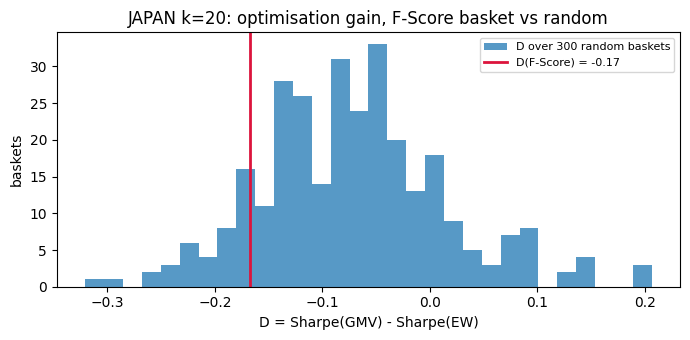

percentile         0.123
p_value            0.877
n_draws          300.000
random_mean       -0.072
random_std         0.087
D_fscore          -0.167
D_random_mean     -0.072
D_random_std       0.087
n                300.000
dtype: float64

In [6]:
syn = study.synergy()
d_rand = (study.mc_metric(study.mc_gmv, "sharpe")
          - study.mc_metric(study.mc_ew[list(range(study.mc_gmv.shape[1]))], "sharpe")).dropna()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(d_rand, bins=30, alpha=0.75, label=f"D over {len(d_rand)} random baskets")
ax.axvline(syn["D_fscore"], color="crimson", lw=2,
           label=f"D(F-Score) = {syn['D_fscore']:.2f}")
ax.set_xlabel("D = Sharpe(GMV) - Sharpe(EW)"); ax.set_ylabel("baskets"); ax.legend(fontsize=8)
ax.set_title(f"{MARKET.upper()} k={K}: optimisation gain, F-Score basket vs random")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_synergy_hist.png", dpi=300)
plt.show()
pd.Series(syn).round(3)

### 5. Track record and outputs

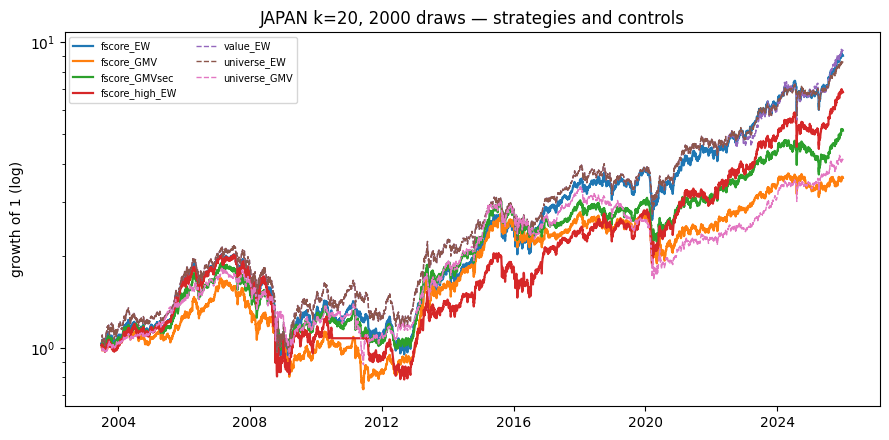

saved japan_k20_mc2000


In [7]:
nav = (1 + study.daily.fillna(0)).cumprod()
fig, ax = plt.subplots(figsize=(9, 4.5))
for c in nav.columns:
    ax.plot(nav.index, nav[c], lw=1.6 if c.startswith("fscore") else 1.0,
            ls="-" if c.startswith("fscore") else "--", label=c)
ax.set_yscale("log"); ax.set_ylabel("growth of 1 (log)"); ax.legend(fontsize=7, ncol=2)
ax.set_title(f"{MARKET.upper()} k={K}, {N_MC} draws — strategies and controls")
plt.tight_layout()
plt.savefig(FIG / f"{TAG}_nav.png", dpi=300)
plt.show()

summary.to_csv(OUT / f"{TAG}_summary.csv")
placement.to_csv(OUT / f"{TAG}_placement.csv")
pd.Series(syn).to_frame("value").to_csv(OUT / f"{TAG}_synergy.csv")
yearly.to_csv(OUT / f"{TAG}_yearly_returns.csv")
diag.to_csv(OUT / f"{TAG}_diagnostics.csv")
print("saved", TAG)